# Explore FreiHAND dataset

Loads the FreiHAND dataset, verifies the local setup, visualizes image variants, checks the canonical train/validation split, and confirms the TensorFlow dataset path.


In [1]:
import sys
from pathlib import Path

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np

from src.data.freihand import FreiHand, SPLIT_SEED, SPLIT_VALIDATION_FRACTION, VARIANTS


## Load and verify


In [2]:
dataset = FreiHand()
dataset.validate()

print(f'Dataset root: {dataset.root}')
print(f'Training samples: {dataset.sample_count}')
print(f'Variants: {VARIANTS}')


Dataset root: /Users/victor/Projects/code/hand-pose-estimation/data/FreiHAND_pub_v2
Training samples: 32560
Variants: ('gs', 'hom', 'sample', 'auto')


## Visualize variants


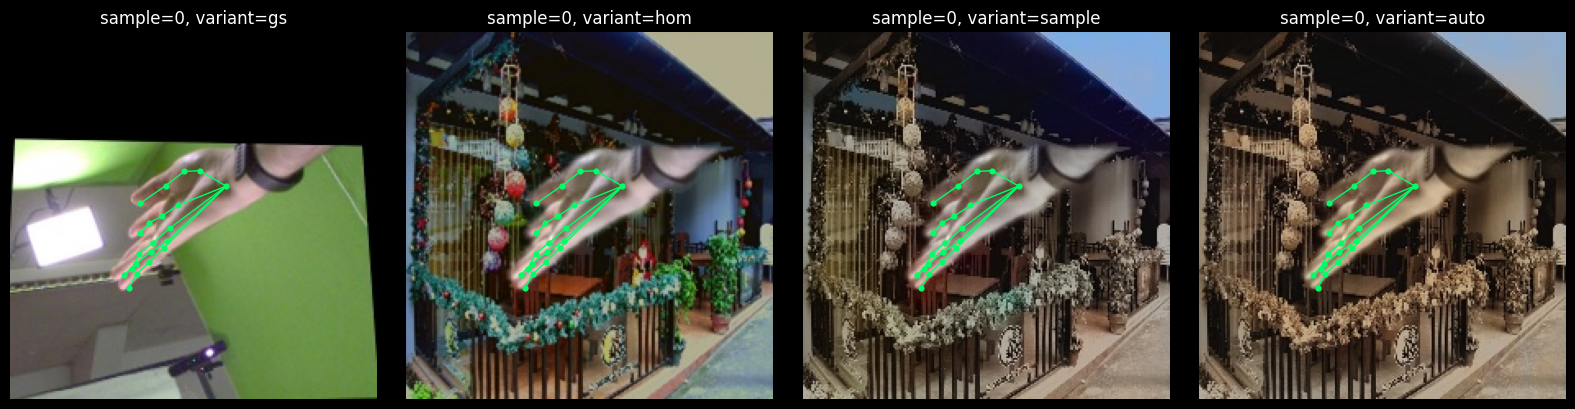

In [3]:
sample_id = 0
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4 * len(VARIANTS), 4))
for ax, variant in zip(axes, VARIANTS):
    dataset.plot_sample(sample_id, variant=variant, ax=ax)
fig.tight_layout()
plt.show()


## Batch loading


In [4]:
sample_ids = [0, 1, 2, 3]
images, keypoints = dataset.load_batch(
    sample_ids,
    image_size=(224, 224),
    flatten_keypoints=False,
)

print('Images:', images.shape, images.dtype, images.min(), images.max())
print('Keypoints:', keypoints.shape, keypoints.dtype)


Images: (4, 224, 224, 3) float32 0.0 1.0
Keypoints: (4, 21, 2) float32


## Canonical split


In [5]:
train_idx, val_idx = dataset.train_validation_split(
    validation_fraction=SPLIT_VALIDATION_FRACTION,
    seed=SPLIT_SEED,
)

print(f'Train samples: {len(train_idx)}')
print(f'Validation samples: {len(val_idx)}')
print('First validation IDs:', val_idx[:10])


Train samples: 29304
Validation samples: 3256
First validation IDs: [ 7025 23902 12821 15974  6232 15103 25563 31931 28525 21689]


## TensorFlow dataset check


In [6]:
tf_ds = dataset.tf_dataset(
    indices=train_idx[:64],
    batch_size=16,
    image_size=(224, 224),
    shuffle=True,
    seed=SPLIT_SEED,
    flatten_keypoints=True,
)

for batch_images, batch_keypoints in tf_ds.take(1):
    print('Image batch:', batch_images.shape, batch_images.dtype)
    print('Keypoint batch:', batch_keypoints.shape, batch_keypoints.dtype)


Image batch: (16, 224, 224, 3) <dtype: 'float32'>
Keypoint batch: (16, 42) <dtype: 'float32'>
